In [1]:
# 1. overall.csv

import pandas as pd
from pathlib import Path

new_columns = ['Model', 'Scope', 
               'Accuracy', 'Precision', 'Recall', 'F1-score', 
               'AVG Tokens', 'AVG Time (sec)']

overall = []
path = Path('results')
for model_dir in path.iterdir():
    if model_dir.is_dir():
        result_file = model_dir / 'result.csv'
        if result_file.exists():
            df = pd.read_csv(result_file)
            df = df.drop(columns=['Trial'])
            df = df.groupby('Scope').mean().reset_index()
            df['Model'] = model_dir.name
            overall.append(df)

overall_df = pd.concat(overall, ignore_index=True)
overall_df = overall_df[new_columns]
overall_save_path = path / 'overall.csv'
overall_df.to_csv(overall_save_path, index=False)
overall_df

,Model,Scope,Accuracy,Precision,Recall,F1-score,AVG Tokens,AVG Time (sec)
0,gemini-2.0-flash,file,0.505745,0.505881,0.852321,0.634898,15875.972340,5.535472
1,gemini-2.0-flash,function,0.515957,0.512655,0.812658,0.628685,2114.187234,3.668103
2,gemini-2.0-flash,repository,0.519787,0.515202,0.809283,0.629549,10356.985106,4.865044
3,llama3.1:8b,file,0.492979,0.498141,0.629114,0.555906,12747.955319,23.774448
4,llama3.1:8b,function,0.514468,0.514046,0.690717,0.589159,1733.644681,22.955464
5,llama3.1:8b,repository,0.490638,0.495700,0.554852,0.523499,8426.253191,24.039162
6,qwen3-coder:30b,file,0.508936,0.541292,0.173418,0.262595,12957.329787,40.713420
7,qwen3-coder:30b,function,0.531702,0.550120,0.392827,0.458183,1749.574468,42.206180
8,qwen3-coder:30b,repository,0.497234,0.503110,0.258650,0.341524,8532.848936,42.173731
9,claude-sonnet-4-5,file,0.518511,0.511768,0.981857,0.672833,16947.176596,19.706942


In [2]:
# 2. overall_table.csv

import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats

def load_raw_data():
    """Load trial-level raw data from all model directories."""
    all_data = []
    path = Path('results')
    for model_dir in path.iterdir():
        if model_dir.is_dir() and model_dir.name != '__pycache__':
            result_file = model_dir / 'result.csv'
            if result_file.exists():
                df = pd.read_csv(result_file)
                df['Model'] = model_dir.name
                all_data.append(df)
    if all_data:
        return pd.concat(all_data, ignore_index=True)
    return None

def cohens_d_paired(group1, group2):
    """Cohen's d for paired samples."""
    diff = group1 - group2
    return diff.mean() / diff.std() if diff.std() != 0 else 0

def significance_marker(p_adj):
    if p_adj < 0.001:
        return '***'
    elif p_adj < 0.01:
        return '**'
    elif p_adj < 0.05:
        return '*'
    else:
        return ''

def paired_ttest(raw_df, scope1, scope2, metric):
    """
    Perform paired t-test between two scopes.
    Pairs matched by (Model, Trial).
    """
    df1 = raw_df[raw_df['Scope'] == scope1][['Model', 'Trial', metric]].copy()
    df2 = raw_df[raw_df['Scope'] == scope2][['Model', 'Trial', metric]].copy()
    
    merged = df1.merge(df2, on=['Model', 'Trial'], suffixes=('_1', '_2'))
    group1 = merged[f'{metric}_1']
    group2 = merged[f'{metric}_2']
    
    # Paired t-test
    t_stat, p_value = stats.ttest_rel(group1, group2)
    
    # Cohen's d
    d = cohens_d_paired(group1, group2)
    
    return {
        't_stat': t_stat,
        'p_value': p_value,
        'cohens_d': d,
        'n_pairs': len(merged)
    }

def wilcoxon_test(raw_df, scope1, scope2, metric):
    """
    Perform Wilcoxon signed-rank test (non-parametric alternative).
    Use when normality assumption is questionable.
    """
    df1 = raw_df[raw_df['Scope'] == scope1][['Model', 'Trial', metric]].copy()
    df2 = raw_df[raw_df['Scope'] == scope2][['Model', 'Trial', metric]].copy()
    
    merged = df1.merge(df2, on=['Model', 'Trial'], suffixes=('_1', '_2'))
    group1 = merged[f'{metric}_1']
    group2 = merged[f'{metric}_2']
    
    # Wilcoxon signed-rank test
    try:
        stat, p_value = stats.wilcoxon(group1, group2)
    except ValueError:  # All differences are zero
        stat, p_value = 0, 1.0
    
    return {
        'statistic': stat,
        'p_value': p_value
    }
    
overall = []
path = Path('results/overall.csv')
df = pd.read_csv(path)
raw_df = load_raw_data()
for scope in ['function', 'file', 'repository']:
    scope_df = df[df['Scope'] == scope].copy()
    
    acc_mean, acc_std = scope_df['Accuracy'].mean(), scope_df['Accuracy'].std()
    pre_mean, pre_std = scope_df['Precision'].mean(), scope_df['Precision'].std()
    rec_mean, rec_std = scope_df['Recall'].mean(), scope_df['Recall'].std()
    f1_mean, f1_std = scope_df['F1-score'].mean(), scope_df['F1-score'].std()
    tok_mean = scope_df['AVG Tokens'].mean()
    time_mean = scope_df['AVG Time (sec)'].mean()
    
    overall.append({
        'Scope': scope.capitalize(),
        'Accuracy': f"{acc_mean:.3f} ± {acc_std:.3f}",
        'Precision': f"{pre_mean:.3f} ± {pre_std:.3f}",
        'Recall': f"{rec_mean:.3f} ± {rec_std:.3f}",
        'F1-score': f"{f1_mean:.3f} ± {f1_std:.3f}",
        'AVG Tokens': f"{tok_mean:.0f}",
        'AVG Time (sec)': f"{time_mean:.2f}"
    })
    
# Improvements between granularities 
improvements = []
comparison_pairs = [
    ('function', 'file'),
    ('file', 'repository'),
    ('repository', 'function')
]
# Number of statistical tests for Bonferroni correction
# 3 comparisons × 4 metrics = 12 tests
n_tests = 12
for g1_lower, g2_lower in comparison_pairs:
    g1 = g1_lower.capitalize()
    g2 = g2_lower.capitalize()
    
    # overall 테이블에서 평균값 가져오기
    row1 = next(item for item in overall if item['Scope'] == g1)
    row2 = next(item for item in overall if item['Scope'] == g2)
    
    # Get mean values from overall table
    improvement_row = {'Scope': f"{g1} vs {g2}"}
    
    # For each metric, calculate improvement and statistical significance
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1-score']:
        mean1 = float(row1[metric].split(' ± ')[0])
        mean2 = float(row2[metric].split(' ± ')[0])
        pct_diff = (mean1 - mean2) * 100  # g1 - g2 (positive = g1 is better)
        
        # Paired t-test with Bonferroni correction
        result = paired_ttest(raw_df, g1_lower, g2_lower, metric)
        p_corrected = min(result['p_value'] * n_tests, 1.0)
        sig = significance_marker(p_corrected)
        p_corrected = f"{p_corrected:.0e}" if p_corrected < 0.001 else f"{p_corrected:.3f}"
        improvement_row[metric] = f"{pct_diff:+.1f}%{sig} (p={p_corrected}, d={result['cohens_d']:.2f})"
    
    # Token and Time differences (no statistical test needed)
    tok1 = float(row1['AVG Tokens'])
    tok2 = float(row2['AVG Tokens'])
    time1 = float(row1['AVG Time (sec)'])
    time2 = float(row2['AVG Time (sec)'])
    
    improvement_row['AVG Tokens'] = f"{int(tok1 - tok2)}"
    improvement_row['AVG Time (sec)'] = f"{time1 - time2:.2f}"
    
    improvements.append(improvement_row)

# Combine and save to overall_table.csv
overall.extend(improvements)
overall_table_df = pd.DataFrame(overall)
overall_table_save_path = Path('results/overall_table.csv')
overall_table_df.to_csv(overall_table_save_path, index=False)
overall_table_df

,Scope,Accuracy,Precision,Recall,F1-score,AVG Tokens,AVG Time (sec)
0,Function,0.527 ± 0.026,0.525 ± 0.020,0.719 ± 0.219,0.592 ± 0.083,1956,29.44
1,File,0.516 ± 0.035,0.516 ± 0.025,0.640 ± 0.314,0.535 ± 0.160,14504,35.66
2,Repository,0.514 ± 0.031,0.511 ± 0.019,0.657 ± 0.274,0.553 ± 0.127,9310,34.61
3,Function vs File,"+1.1%** (p=0.001, d=0.46)","+0.9%* (p=0.036, d=0.34)","+7.9%*** (p=6e-09, d=0.79)","+5.7%*** (p=3e-08, d=0.76)",-12548,-6.22
4,File vs Repository,"+0.2% (p=1.000, d=0.11)","+0.5% (p=0.557, d=0.23)","-1.7% (p=0.152, d=-0.29)","-1.8%** (p=0.003, d=-0.43)",5194,1.05
5,Repository vs Function,"-1.3%*** (p=1e-04, d=-0.53)","-1.4%*** (p=4e-05, d=-0.56)","-6.2%*** (p=8e-12, d=-0.96)","-3.9%*** (p=1e-10, d=-0.89)",7354,5.17


In [3]:
for _, row in overall_table_df.iterrows():
    print(f"{row['Scope']} & {row['Accuracy'].replace('±', '$\\pm$')} & {row['Precision'].replace('±', '$\\pm$')} & {row['Recall'].replace('±', '$\\pm$')} & {row['F1-score'].replace('±', '$\\pm$')} & {row['AVG Tokens'].replace('±', '$\\pm$')} & {row['AVG Time (sec)'].replace('±', '$\\pm$')} \\\\")

Function & 0.527 $\pm$ 0.026 & 0.525 $\pm$ 0.020 & 0.719 $\pm$ 0.219 & 0.592 $\pm$ 0.083 & 1956 & 29.44 \\
File & 0.516 $\pm$ 0.035 & 0.516 $\pm$ 0.025 & 0.640 $\pm$ 0.314 & 0.535 $\pm$ 0.160 & 14504 & 35.66 \\
Repository & 0.514 $\pm$ 0.031 & 0.511 $\pm$ 0.019 & 0.657 $\pm$ 0.274 & 0.553 $\pm$ 0.127 & 9310 & 34.61 \\
Function vs File & +1.1%** (p=0.001, d=0.46) & +0.9%* (p=0.036, d=0.34) & +7.9%*** (p=6e-09, d=0.79) & +5.7%*** (p=3e-08, d=0.76) & -12548 & -6.22 \\
File vs Repository & +0.2% (p=1.000, d=0.11) & +0.5% (p=0.557, d=0.23) & -1.7% (p=0.152, d=-0.29) & -1.8%** (p=0.003, d=-0.43) & 5194 & 1.05 \\
Repository vs Function & -1.3%*** (p=1e-04, d=-0.53) & -1.4%*** (p=4e-05, d=-0.56) & -6.2%*** (p=8e-12, d=-0.96) & -3.9%*** (p=1e-10, d=-0.89) & 7354 & 5.17 \\


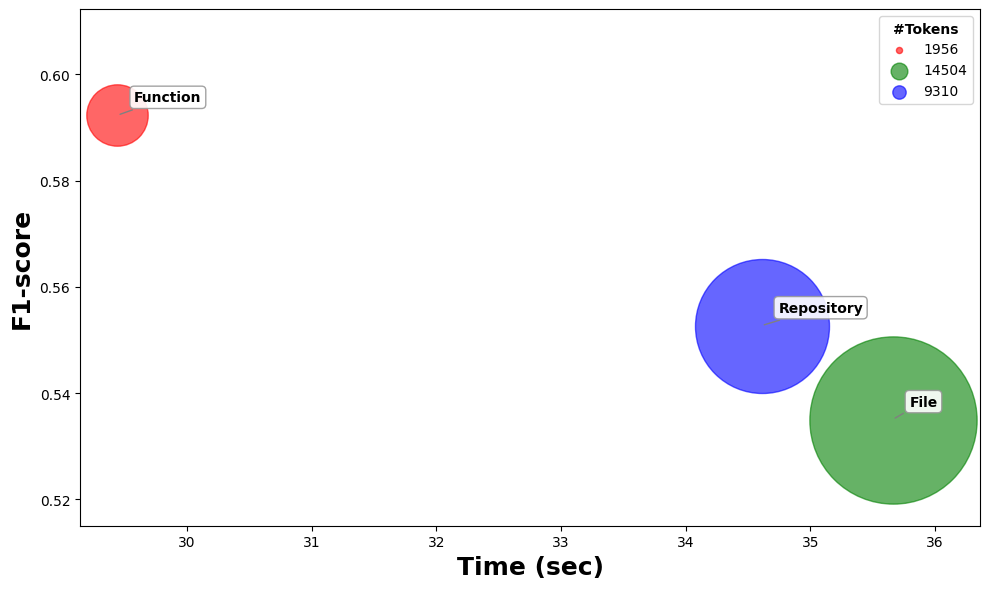

In [4]:
# 3. tradeoff.png

import pandas as pd
import matplotlib.pyplot as plt

overall_df = pd.read_csv('results/overall.csv')
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'function': 'red', 'file': 'green', 'repository': 'blue'}
times, f1s = [], []
for scope in colors.keys():
    scope_df = overall_df[overall_df['Scope'] == scope]
    f1_mean = scope_df['F1-score'].mean()
    time_mean = scope_df['AVG Time (sec)'].mean()
    tok_mean = scope_df['AVG Tokens'].mean()
    times.append(time_mean)
    f1s.append(f1_mean)
    plt.scatter(time_mean, f1_mean, s=tok_mean, 
                color=colors[scope], alpha=0.6, label=f"{tok_mean:.0f}")
    plt.annotate(
        scope.capitalize(),
        (time_mean, f1_mean),
        xytext=(12, 10),
        textcoords="offset points",
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.6", alpha=0.9),
        arrowprops=dict(arrowstyle="-", color="0.5", lw=1.0),
    )

x_min, x_max = min(times), max(times)
y_min, y_max = min(f1s), max(f1s)

ax.set_xlim(x_min - 0.3, x_max + 0.7)
ax.set_ylim(y_min - 0.02, y_max + 0.02)

ax.set_xlabel('Time (sec)', fontdict={'weight': 'bold', 'size': 18})
ax.set_ylabel('F1-score', fontdict={'weight': 'bold', 'size': 18})
leg = ax.legend(title='#Tokens', markerscale=0.1)
leg.get_title().set_weight('bold')
# plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('results/tradeoff.png')
plt.show()

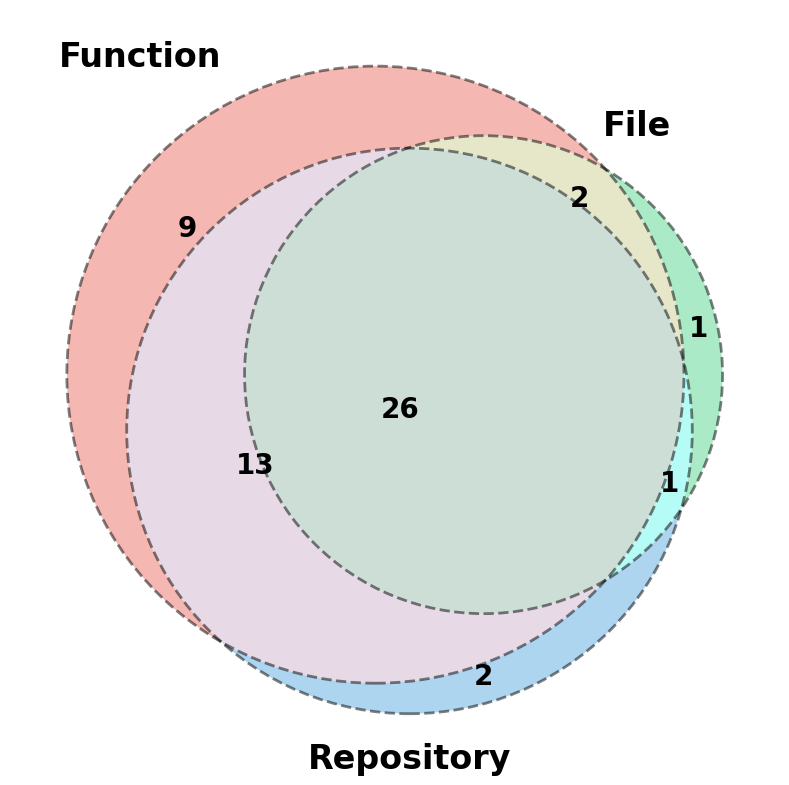

[Function-only] (9) ['CWE-121', 'CWE-1284', 'CWE-189', 'CWE-388', 'CWE-415', 'CWE-416', 'CWE-75', 'CWE-798', 'CWE-90']
[File-only] (1) ['CWE-254']
[Repository-only] (2) ['CWE-287', 'CWE-613']


In [5]:
# 4. cwe_venn_diagram.png

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn3_circles
from sklearn.metrics import f1_score
from pathlib import Path
import numpy as np
import warnings
warnings.filterwarnings("ignore")

def convert_to_bool(val):
    if isinstance(val, bool):
        return val
    if isinstance(val, (int, float)):
        if val == 1 or val == 1.0:
            return True
        elif val == 0 or val == 0.0:
            return False
    if isinstance(val, str):
        if val.lower() == 'true':
            return True
        elif val.lower() == 'false':
            return False
    return None

def print_venn_unique_ids(function_set, file_set, repository_set):
    func_only = sorted(function_set - file_set - repository_set)
    file_only = sorted(file_set - function_set - repository_set)
    repo_only = sorted(repository_set - function_set - file_set)
    print(f"[Function-only] ({len(func_only)}) {func_only}")
    print(f"[File-only] ({len(file_only)}) {file_only}")
    print(f"[Repository-only] ({len(repo_only)}) {repo_only}")
    
path = Path('results')
cwe_scope_dict = {'function': dict(), 'file': dict(), 'repository': dict()}
for model_dir in path.iterdir():
    if model_dir.is_dir():
        for jsonl_file in model_dir.glob('FuncFileRepo_*.jsonl'):
            df = pd.read_json(jsonl_file, lines=True)
            for scope in cwe_scope_dict.keys():
                scope_df = df[df['scope'] == scope]
                scope_df = scope_df.copy()
                scope_df = scope_df.dropna(subset=['predict', 'vulnerable', 'cwe_id'])
                if scope_df.empty:
                    continue
                scope_df['predict'] = scope_df['predict'].apply(convert_to_bool)
                scope_df['vulnerable'] = scope_df['vulnerable']
                scope_df = scope_df.dropna(subset=['predict', 'vulnerable'])

                cwe_f1_scores = {}
                for _, row in scope_df.iterrows():
                    cwe_ids = row['cwe_id']
                    y_true = row['vulnerable']
                    y_pred = row['predict']
                    for cwe_id in cwe_ids:
                        if cwe_id not in cwe_f1_scores:
                            cwe_f1_scores[cwe_id] = {'y_true': [], 'y_pred': []}
                        cwe_f1_scores[cwe_id]['y_true'].append(y_true)
                        cwe_f1_scores[cwe_id]['y_pred'].append(y_pred)
                for cwe_id, scores in cwe_f1_scores.items():
                    f1 = f1_score(scores['y_true'], scores['y_pred'])
                    if cwe_id not in cwe_scope_dict[scope]:
                        cwe_scope_dict[scope][cwe_id] = []
                    cwe_scope_dict[scope][cwe_id].append(f1)
for scope in cwe_scope_dict.keys():
    for cwe_id in cwe_scope_dict[scope].keys():
        f1_scores = cwe_scope_dict[scope][cwe_id]
        avg_f1 = sum(f1_scores) / len(f1_scores)
        cwe_scope_dict[scope][cwe_id] = avg_f1
all_cwe_ids = set()
for scope in cwe_scope_dict.keys():
    all_cwe_ids.update(cwe_scope_dict[scope].keys())
data = []
for cwe_id in all_cwe_ids:
    row = {'CWE ID': cwe_id}
    for scope in ['function', 'file', 'repository']:
        row[scope] = cwe_scope_dict[scope].get(cwe_id, None)
    data.append(row)
df_result = pd.DataFrame(data)

threshold = 0.5
plt.figure(figsize=(8, 8))
function_set = set(df_result[df_result['function'] >= threshold]['CWE ID'].dropna())
file_set = set(df_result[df_result['file'] >= threshold]['CWE ID'].dropna())
repository_set = set(df_result[df_result['repository'] >= threshold]['CWE ID'].dropna())
venn = venn3([function_set, file_set, repository_set], 
                set_labels=('Function', 'File', 'Repository'),
                set_colors=('#e74c3c', '#2ecc71', '#3498db'))
venn3_circles([function_set, file_set, repository_set], linestyle='dashed', alpha=0.5)

# def _label_text(cwes: set) -> str:
#     if not cwes:
#         return ""
#     cwe_str = ""
#     for i, cwe in enumerate(sorted(cwes), 1):
#         cwe_str += cwe
#         if i % 1 == 0:
#             cwe_str += "\n"
#         else:
#             cwe_str += ", "
#     return cwe_str.rstrip(", ")
# regions = {
#     "100": function_set - file_set - repository_set,
#     "010": file_set - function_set - repository_set,
#     "001": repository_set - function_set - file_set,
#     "110": (function_set & file_set) - repository_set,
#     "101": (function_set & repository_set) - file_set,
#     "011": (file_set & repository_set) - function_set,
#     "111": function_set & file_set & repository_set,
# }
# labels = {
#     "100": venn.get_label_by_id("100"),
#     "010": venn.get_label_by_id("010"),
#     "001": venn.get_label_by_id("001"),
#     "110": venn.get_label_by_id("110"),
#     "101": venn.get_label_by_id("101"),
#     "011": venn.get_label_by_id("011"),
#     "111": venn.get_label_by_id("111"),
# }
# for key, label in labels.items():
#     if label is not None:
#         label.set_text(_label_text(regions[key]))
#         label.set_fontsize(10)
#         label.set_fontweight('bold')

# plt set fontsize and fontweight
for text in venn.set_labels:
    text.set_fontsize(24)
    text.set_fontweight('bold')
for text in venn.subset_labels:
    if text is not None:
        text.set_fontsize(20)
        text.set_fontweight('bold')
plt.tight_layout()
plt.savefig('results/cwe_venn_diagram.png')
plt.show()
print_venn_unique_ids(function_set, file_set, repository_set)

In [6]:
# 5. best_cwe_table.csv, worst_cwe_table.csv, top25_cwe_table.csv

import re
import html
import requests
import pandas as pd
from sklearn.metrics import f1_score
from bs4 import BeautifulSoup
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

def convert_to_bool(val):
    if isinstance(val, bool):
        return val
    if isinstance(val, (int, float)):
        if val == 1 or val == 1.0:
            return True
        elif val == 0 or val == 0.0:
            return False
    if isinstance(val, str):
        if val.lower() == 'true':
            return True
        elif val.lower() == 'false':
            return False
    return None

def get_cwe_name(cwe_id:str) -> str:
    if cwe_id == 'NVD-CWE-noinfo':
        return cwe_id
    match = re.match(r"CWE-(\d+)", cwe_id)
    cwe_id = match.group(1)
    url = f"https://cwe.mitre.org/data/definitions/{cwe_id}.html"
    resp = requests.get(url, timeout=10)
    if resp.status_code == 200:
        title_match = re.search(rf"CWE-{cwe_id}:\s*([^<]+)", resp.text)
        if title_match:
            name = html.unescape(title_match.group(1).strip())
            name = name.replace('CWE CATEGORY: ', '')
            name = name.replace(' (4.19)', '')
            return name
    return cwe_id

def get_top25_cwes():
    url = "https://cwe.mitre.org/top25/archive/2025/2025_cwe_top25.html"
    try:
        resp = requests.get(url, timeout=10)
        if resp.status_code == 200:
            soup = BeautifulSoup(resp.text, 'html.parser')
            
            cwe_pattern = re.compile(r'CWE-(\d+)')
            cwe_ids = []
            
            table = soup.find('table')
            if table:
                rows = table.find_all('tr')
                for row in rows:
                    cells = row.find_all('td')
                    if cells:
                        first_cell_text = cells[0].get_text()
                        match = cwe_pattern.search(first_cell_text)
                        if match:
                            cwe_id = f"CWE-{match.group(1)}"
                            if cwe_id not in cwe_ids:
                                cwe_ids.append(cwe_id)
            
            if not cwe_ids:
                all_text = soup.get_text()
                matches = cwe_pattern.findall(all_text)
                seen = set()
                for match in matches:
                    cwe_id = f"CWE-{match}"
                    if cwe_id not in seen:
                        seen.add(cwe_id)
                        cwe_ids.append(cwe_id)
                        if len(cwe_ids) >= 25:
                            break
            return cwe_ids[:25]
    except Exception as e:
        print(f"Error fetching Top 25 CWEs: {e}")
        return []


path = Path('results')
cwe_scope_dict = {'function': dict(), 'file': dict(), 'repository': dict()}
for model_dir in path.iterdir():
    if model_dir.is_dir():
        for jsonl_file in model_dir.glob('FuncFileRepo_*.jsonl'):
            df = pd.read_json(jsonl_file, lines=True)
            for scope in cwe_scope_dict.keys():
                scope_df = df[df['scope'] == scope]
                scope_df = scope_df.copy()
                scope_df = scope_df.dropna(subset=['predict', 'vulnerable', 'cwe_id'])
                if scope_df.empty:
                    continue
                scope_df['predict'] = scope_df['predict'].apply(convert_to_bool)
                scope_df['vulnerable'] = scope_df['vulnerable']
                cwe_f1_scores = {}
                for _, row in scope_df.iterrows():
                    cwe_ids = row['cwe_id']
                    y_true = row['vulnerable']
                    y_pred = row['predict']
                    for cwe_id in cwe_ids:
                        if cwe_id not in cwe_f1_scores:
                            cwe_f1_scores[cwe_id] = {'y_true': [], 'y_pred': []}
                        cwe_f1_scores[cwe_id]['y_true'].append(y_true)
                        cwe_f1_scores[cwe_id]['y_pred'].append(y_pred)
                for cwe_id, scores in cwe_f1_scores.items():
                    f1 = f1_score(scores['y_true'], scores['y_pred'])
                    if cwe_id not in cwe_scope_dict[scope]:
                        cwe_scope_dict[scope][cwe_id] = []
                    cwe_scope_dict[scope][cwe_id].append(f1)

for scope in cwe_scope_dict.keys():
    for cwe_id in cwe_scope_dict[scope].keys():
        f1_scores = cwe_scope_dict[scope][cwe_id]
        avg_f1 = sum(f1_scores) / len(f1_scores)
        cwe_scope_dict[scope][cwe_id] = avg_f1
        
all_cwe_ids = set()
for scope in cwe_scope_dict.keys():
    all_cwe_ids.update(cwe_scope_dict[scope].keys())

data = []
for cwe_id in all_cwe_ids:
    row = {'CWE ID': cwe_id}
    for scope in ['function', 'file', 'repository']:
        row[scope] = cwe_scope_dict[scope].get(cwe_id, None)
    data.append(row)

df_result = pd.DataFrame(data)
df_result['Total'] = df_result[['function', 'file', 'repository']].sum(axis=1, skipna=True)
df_result['CWE Name'] = df_result['CWE ID'].apply(get_cwe_name)
df_result = df_result.rename(columns={
    'function': 'Function',
    'file': 'File',
    'repository': 'Repository'
})
df_result = df_result[['CWE ID', 'CWE Name', 'Function', 'File', 'Repository', 'Total']]

# Best 5 CWEs
best5_cwe = df_result.sort_values(by='Total', ascending=False).head(5).reset_index(drop=True).copy()
best5_cwe = best5_cwe[['CWE ID', 'CWE Name', 'Function', 'File', 'Repository']]
best5_cwe.to_csv('results/best_cwe_table.csv', index=False)
display(best5_cwe)

# Worst 5 CWEs
worst5_cwe = df_result.sort_values(by='Total', ascending=True).head(5).reset_index(drop=True).copy()
worst5_cwe = worst5_cwe[['CWE ID', 'CWE Name', 'Function', 'File', 'Repository']]
worst5_cwe.to_csv('results/worst_cwe_table.csv', index=False)
display(worst5_cwe)

# 2025 CWE Top 25 Most Dangerous Software Weaknesses
TOP25_2025 = get_top25_cwes()
if not TOP25_2025:
    print("Failed to extract Top 25 CWEs. Using fallback list.")
    TOP25_2025 = [
        'CWE-79', 'CWE-787', 'CWE-89', 'CWE-22', 'CWE-352',
        'CWE-434', 'CWE-862', 'CWE-476', 'CWE-77', 'CWE-125',
        'CWE-78', 'CWE-416', 'CWE-502', 'CWE-287', 'CWE-269',
        'CWE-20', 'CWE-94', 'CWE-863', 'CWE-918', 'CWE-306',
        'CWE-119', 'CWE-798', 'CWE-190', 'CWE-401', 'CWE-617'
    ]
top25_in_dataset = [cwe for cwe in TOP25_2025 if cwe in all_cwe_ids]
top25_cwe = df_result[df_result['CWE ID'].isin(top25_in_dataset)].reset_index(drop=True).copy()
top25_cwe = top25_cwe[['CWE ID', 'CWE Name', 'Function', 'File', 'Repository']]
top25_cwe.to_csv('results/top25_cwe_table.csv', index=False)
display(top25_cwe)

,CWE ID,CWE Name,Function,File,Repository
0,CWE-346,Origin Validation Error,0.900000,0.912500,0.900000
1,CWE-89,Improper Neutralization of Special Elements us...,0.674605,0.626188,0.641625
2,CWE-284,Improper Access Control,0.662500,0.629167,0.612500
3,CWE-611,Improper Restriction of XML External Entity Re...,0.652868,0.649013,0.587120
4,CWE-1336,Improper Neutralization of Special Elements Us...,0.683333,0.562500,0.633333


,CWE ID,CWE Name,Function,File,Repository
0,CWE-369,Divide By Zero,0.275000,0.187500,0.237500
1,CWE-320,Key Management Errors,0.350000,0.258333,0.314286
2,CWE-273,Improper Check for Dropped Privileges,0.337500,0.287500,0.300000
3,CWE-400,Uncontrolled Resource Consumption,0.320833,0.370833,0.358333
4,CWE-116,Improper Encoding or Escaping of Output,0.479167,0.366667,0.245833


,CWE ID,CWE Name,Function,File,Repository
0,CWE-20,Improper Input Validation,0.591405,0.527119,0.551886
1,CWE-125,Out-of-bounds Read,0.569469,0.528237,0.537718
2,CWE-284,Improper Access Control,0.662500,0.629167,0.612500
3,CWE-22,Improper Limitation of a Pathname to a Restric...,0.605221,0.542297,0.559290
4,CWE-77,Improper Neutralization of Special Elements us...,0.608317,0.552587,0.601835
5,CWE-78,Improper Neutralization of Special Elements us...,0.597722,0.564927,0.595814
6,CWE-120,Buffer Copy without Checking Size of Input ('C...,0.625921,0.552516,0.604775
7,CWE-476,NULL Pointer Dereference,0.625816,0.474605,0.555798
8,CWE-89,Improper Neutralization of Special Elements us...,0.674605,0.626188,0.641625
9,CWE-502,Deserialization of Untrusted Data,0.575000,0.441667,0.604167


In [7]:
for _, row in best5_cwe.iterrows():
    print(f"{row['CWE ID']} & {row['CWE Name']} & {row['Function']:.3f} & {row['File']:.3f} & {row['Repository']:.3f} \\\\")

print()

for _, row in worst5_cwe.iterrows():
    print(f"{row['CWE ID']} & {row['CWE Name']} & {row['Function']:.3f} & {row['File']:.3f} & {row['Repository']:.3f} \\\\")

CWE-346 & Origin Validation Error & 0.900 & 0.912 & 0.900 \\
CWE-89 & Improper Neutralization of Special Elements used in an SQL Command ('SQL Injection') & 0.675 & 0.626 & 0.642 \\
CWE-284 & Improper Access Control & 0.662 & 0.629 & 0.613 \\
CWE-611 & Improper Restriction of XML External Entity Reference & 0.653 & 0.649 & 0.587 \\
CWE-1336 & Improper Neutralization of Special Elements Used in a Template Engine & 0.683 & 0.562 & 0.633 \\

CWE-369 & Divide By Zero & 0.275 & 0.188 & 0.237 \\
CWE-320 & Key Management Errors & 0.350 & 0.258 & 0.314 \\
CWE-273 & Improper Check for Dropped Privileges & 0.338 & 0.287 & 0.300 \\
CWE-400 & Uncontrolled Resource Consumption & 0.321 & 0.371 & 0.358 \\
CWE-116 & Improper Encoding or Escaping of Output & 0.479 & 0.367 & 0.246 \\


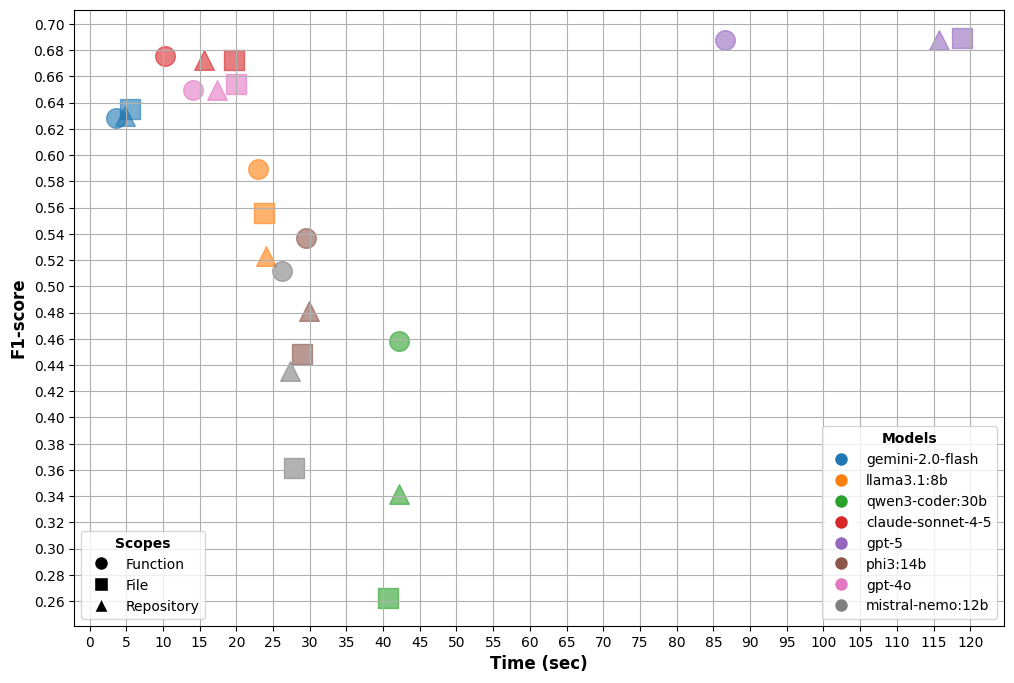

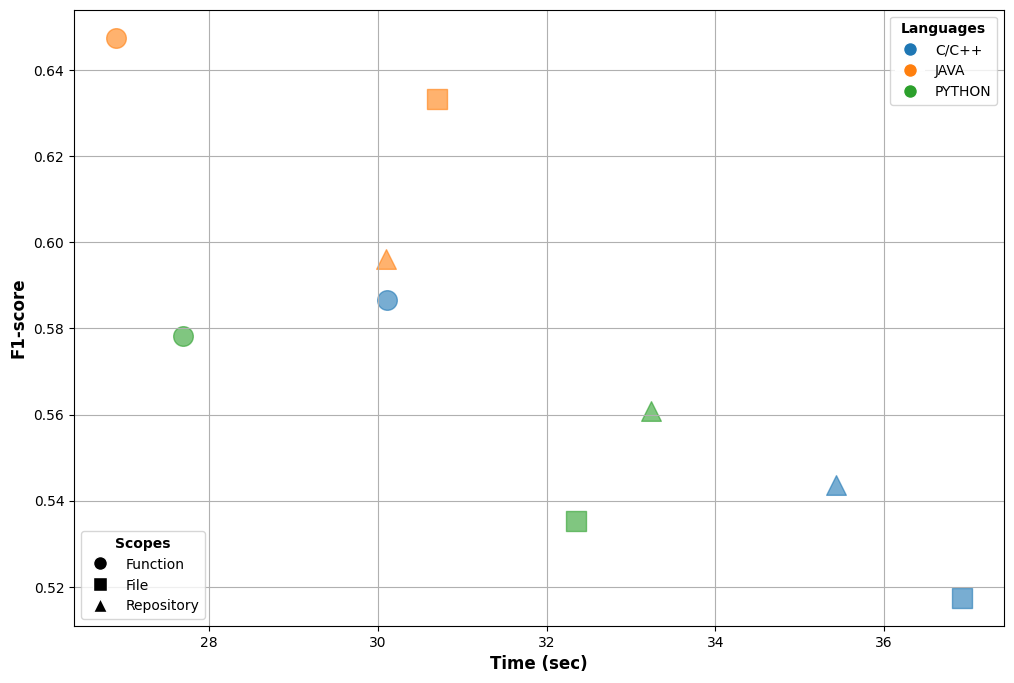

In [8]:
# 6. model_tradeoff.png, language_tradeoff.png

import pandas as pd
from pathlib import Path
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
import warnings
warnings.filterwarnings("ignore")

model_data = {}
language_data = {}
path = Path('results')
for model_dir in path.iterdir():
    if model_dir.is_dir():
        model_name = model_dir.name
        model_data.setdefault(model_name, dict())
        for jsonl_file in model_dir.glob('FuncFileRepo_*.jsonl'):
            df = pd.read_json(jsonl_file, lines=True)
            for scope in df['scope'].unique():
                scope_df = df[df['scope'] == scope]
                scope_df = scope_df.copy()
                scope_df = scope_df.dropna(subset=['predict', 'vulnerable'])
                if scope_df.empty:
                    continue
                scope_df['predict'] = scope_df['predict'].apply(convert_to_bool)
                scope_df['vulnerable'] = scope_df['vulnerable']
                y_true = scope_df['vulnerable']
                y_pred = scope_df['predict']
                time_sec = scope_df['Time (sec)'].mean()
                f1 = f1_score(y_true, y_pred)
                if scope not in model_data[model_name]:
                    model_data[model_name][scope] = {'f1_scores': [], 'times': []}
                model_data[model_name][scope]['f1_scores'].append(f1)
                model_data[model_name][scope]['times'].append(time_sec)
            
            for language in ['c/c++', 'java', 'python']:
                language_data.setdefault(language, dict())
                for scope in df['scope'].unique():
                    if language == 'c/c++':
                        lang_scope_df = df[((df['language'] == 'c') | (df['language'] == 'c++')) & (df['scope'] == scope)]
                    else:
                        lang_scope_df = df[(df['language'] == language) & (df['scope'] == scope)]
                    lang_scope_df = lang_scope_df.copy()
                    lang_scope_df = lang_scope_df.dropna(subset=['predict', 'vulnerable'])
                    if lang_scope_df.empty:
                        continue
                    lang_scope_df['predict'] = lang_scope_df['predict'].apply(convert_to_bool)
                    lang_scope_df['vulnerable'] = lang_scope_df['vulnerable']
                    y_true = lang_scope_df['vulnerable']
                    y_pred = lang_scope_df['predict']
                    time_sec = lang_scope_df['Time (sec)'].mean()
                    f1 = f1_score(y_true, y_pred)
                    if scope not in language_data[language]:
                        language_data[language][scope] = {'f1_scores': [], 'times': []}
                    language_data[language][scope]['f1_scores'].append(f1)
                    language_data[language][scope]['times'].append(time_sec)


# Model Tradeoff Plot
fig, ax = plt.subplots(figsize=(12, 8))
markers = {'function': 'o', 'file': 's', 'repository': '^'}
colors = plt.cm.tab10(range(len(model_data)))
model_colors = {model: colors[i] for i, model in enumerate(model_data.keys())}

for model_name, scopes in model_data.items():
    for scope, metrics in scopes.items():
        f1_mean = sum(metrics['f1_scores']) / len(metrics['f1_scores'])
        time_mean = sum(metrics['times']) / len(metrics['times'])
        plt.scatter(time_mean, f1_mean, s=200, alpha=0.6, 
                    color=model_colors[model_name],
                    marker=markers.get(scope, 'o'))

ax.xaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_major_locator(MultipleLocator(0.02))

# Create custom legends
model_legend_elements = [Line2D([0], [0], marker='o', color='w', 
                                markerfacecolor=model_colors[model], 
                                markersize=10, label=model)
                         for model in model_data.keys()]
scope_legend_elements = [Line2D([0], [0], marker=markers[scope], color='w', 
                                markerfacecolor='black', 
                                markersize=10, label=scope.capitalize())
                         for scope in ['function', 'file', 'repository']]

first_legend = plt.legend(handles=model_legend_elements, title='Models', 
                          loc='lower right', title_fontproperties={'weight': 'bold'})
plt.gca().add_artist(first_legend)
plt.legend(handles=scope_legend_elements, title='Scopes', 
           loc='lower left', title_fontproperties={'weight': 'bold'})

plt.xlabel('Time (sec)', fontdict={'weight': 'bold', 'size': 12})
plt.ylabel('F1-score', fontdict={'weight': 'bold', 'size': 12})
plt.grid(True)
plt.savefig('results/model_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()

# Language Tradeoff Plot
plt.subplots(figsize=(12, 8))
colors = plt.cm.tab10(range(len(language_data)))
language_colors = {language: colors[i] for i, language in enumerate(language_data.keys())}

for language, scopes in language_data.items():
    for scope, metrics in scopes.items():
        f1_mean = sum(metrics['f1_scores']) / len(metrics['f1_scores'])
        time_mean = sum(metrics['times']) / len(metrics['times'])
        plt.scatter(time_mean, f1_mean, s=200, alpha=0.6, 
                    color=language_colors[language],
                    marker=markers.get(scope, 'o'))

# Create custom legends
language_legend_elements = [Line2D([0], [0], marker='o', color='w', 
                                   markerfacecolor=language_colors[language], 
                                   markersize=10, label=language.upper())
                            for language in language_data.keys()]
scope_legend_elements = [Line2D([0], [0], marker=markers[scope], color='w', 
                                markerfacecolor='black', 
                                markersize=10, label=scope.capitalize())
                         for scope in ['function', 'file', 'repository']]

first_legend = plt.legend(handles=language_legend_elements, title='Languages', 
                          loc='upper right', title_fontproperties={'weight': 'bold'})
plt.gca().add_artist(first_legend)
plt.legend(handles=scope_legend_elements, title='Scopes', 
           loc='lower left', title_fontproperties={'weight': 'bold'})

plt.xlabel('Time (sec)', fontdict={'weight': 'bold', 'size': 12})
plt.ylabel('F1-score', fontdict={'weight': 'bold', 'size': 12})
plt.grid(True)
plt.savefig('results/language_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()

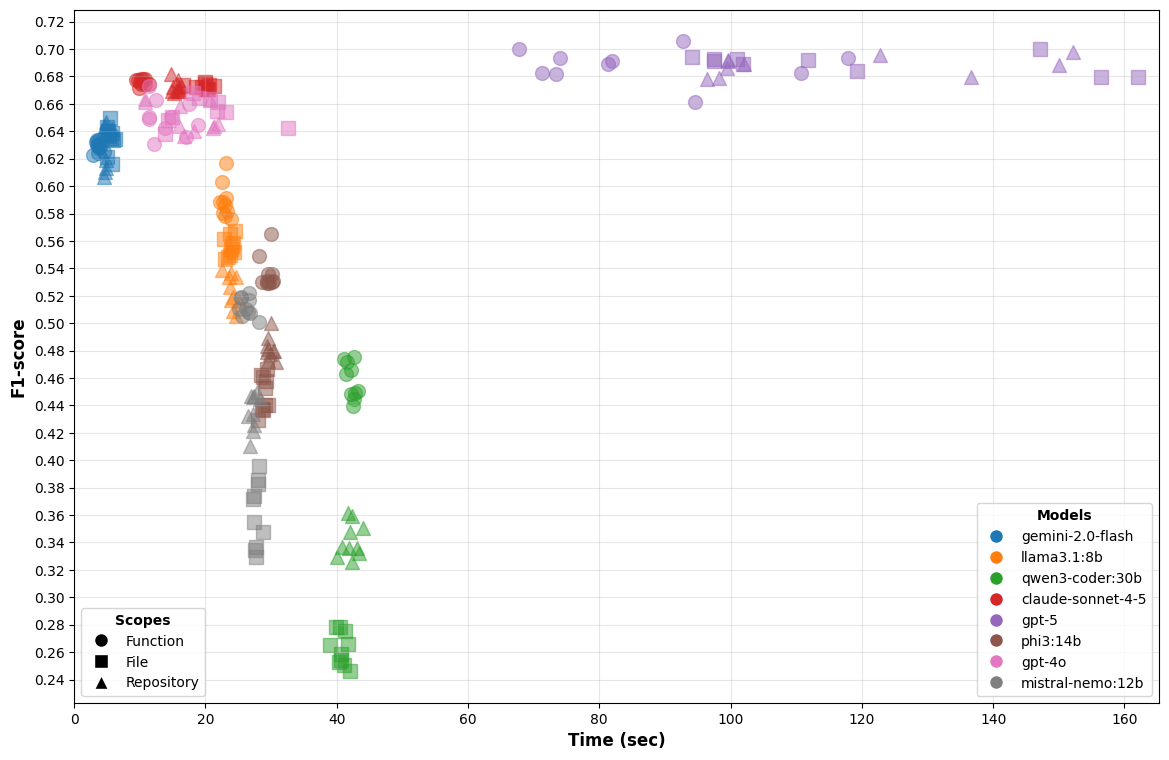

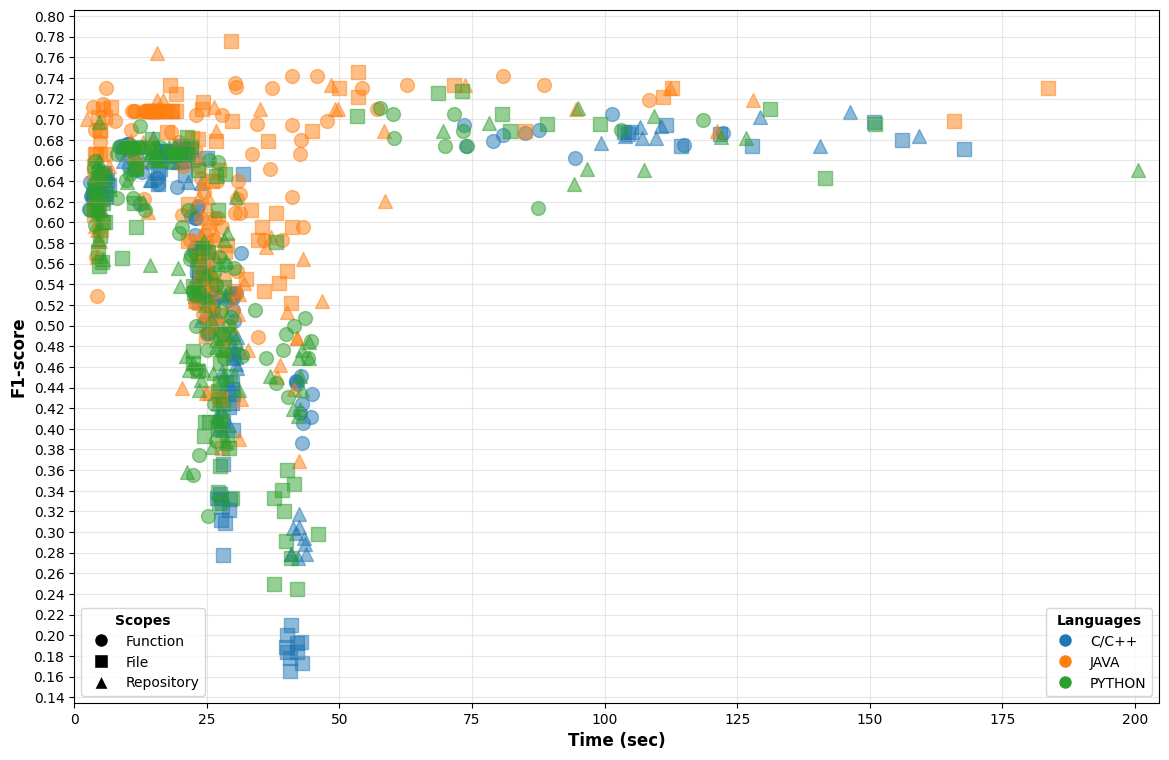

In [9]:
# 6. Individual model and language tradeoff plots

import math
import pandas as pd
from pathlib import Path
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
import warnings
warnings.filterwarnings("ignore")

def convert_to_bool(value):
    """Convert various boolean representations to bool"""
    if isinstance(value, bool):
        return value
    if isinstance(value, str):
        return value.lower() in ['true', '1', 'yes']
    return bool(value)

# Collect data
model_data = {}
language_data = {}
path = Path('results')

for model_dir in path.iterdir():
    if model_dir.is_dir():
        model_name = model_dir.name
        model_data.setdefault(model_name, dict())
        
        for jsonl_file in model_dir.glob('FuncFileRepo_*.jsonl'):
            trial_name = jsonl_file.stem  # e.g., 'FuncFileRepo_1'
            df = pd.read_json(jsonl_file, lines=True)
            
            # Process each scope for this trial
            for scope in df['scope'].unique():
                scope_df = df[df['scope'] == scope]
                scope_df = scope_df.copy()
                scope_df = scope_df.dropna(subset=['predict', 'vulnerable'])
                if scope_df.empty:
                    continue
                    
                scope_df['predict'] = scope_df['predict'].apply(convert_to_bool)
                scope_df['vulnerable'] = scope_df['vulnerable']
                y_true = scope_df['vulnerable']
                y_pred = scope_df['predict']
                time_sec = scope_df['Time (sec)'].mean()
                f1 = f1_score(y_true, y_pred)
                
                if scope not in model_data[model_name]:
                    model_data[model_name][scope] = {'trials': []}
                
                model_data[model_name][scope]['trials'].append({
                    'trial': trial_name,
                    'f1': f1,
                    'time': time_sec
                })
            
            # Process each language
            for language in ['c/c++', 'java', 'python']:
                language_data.setdefault(language, dict())
                
                for scope in df['scope'].unique():
                    if language == 'c/c++':
                        lang_scope_df = df[((df['language'] == 'c') | (df['language'] == 'c++')) & (df['scope'] == scope)]
                    else:
                        lang_scope_df = df[(df['language'] == language) & (df['scope'] == scope)]
                    
                    lang_scope_df = lang_scope_df.copy()
                    lang_scope_df = lang_scope_df.dropna(subset=['predict', 'vulnerable'])
                    if lang_scope_df.empty:
                        continue
                        
                    lang_scope_df['predict'] = lang_scope_df['predict'].apply(convert_to_bool)
                    lang_scope_df['vulnerable'] = lang_scope_df['vulnerable']
                    y_true = lang_scope_df['vulnerable']
                    y_pred = lang_scope_df['predict']
                    time_sec = lang_scope_df['Time (sec)'].mean()
                    f1 = f1_score(y_true, y_pred)
                    
                    if scope not in language_data[language]:
                        language_data[language][scope] = {'trials': []}
                    
                    language_data[language][scope]['trials'].append({
                        'trial': trial_name,
                        'f1': f1,
                        'time': time_sec
                    })

# Plot settings
markers = {'function': 'o', 'file': 's', 'repository': '^'}
scope_colors = {'function': '#1f77b4', 'file': '#ff7f0e', 'repository': '#2ca02c'}

# ========================================
# 1. Individual Model Tradeoff Plots (8 plots)
# ========================================
# for model_name, scopes in model_data.items():
#     fig, ax = plt.subplots(figsize=(10, 7))
    
#     for scope, data in scopes.items():
#         trials = data['trials']
#         f1_scores = [t['f1'] for t in trials]
#         times = [t['time'] for t in trials]
        
#         # Plot each trial as a point
#         plt.scatter(times, f1_scores, s=150, alpha=0.7,
#                    color=scope_colors[scope],
#                    marker=markers[scope],
#                    label=scope.capitalize())
    
#     # Formatting
#     ax.xaxis.set_major_locator(MultipleLocator(5))
#     ax.yaxis.set_major_locator(MultipleLocator(0.05))
    
#     plt.xlabel('Time (sec)', fontdict={'weight': 'bold', 'size': 12})
#     plt.ylabel('F1-score', fontdict={'weight': 'bold', 'size': 12})
#     plt.title(f'{model_name}', fontdict={'weight': 'bold', 'size': 14})
#     plt.legend(title='Scopes', title_fontproperties={'weight': 'bold'}, loc='best')
#     plt.grid(True, alpha=0.3)
#     plt.show()
#     plt.close()

# ========================================
# 2. Individual Language Tradeoff Plots (3 plots)
# ========================================
# for language, scopes in language_data.items():
#     fig, ax = plt.subplots(figsize=(10, 7))
    
#     for scope, data in scopes.items():
#         trials = data['trials']
#         f1_scores = [t['f1'] for t in trials]
#         times = [t['time'] for t in trials]
        
#         # Plot each trial as a point
#         plt.scatter(times, f1_scores, s=150, alpha=0.7,
#                    color=scope_colors[scope],
#                    marker=markers[scope],
#                    label=scope.capitalize())
    
#     # Formatting
#     ax.xaxis.set_major_locator(MultipleLocator(5))
#     ax.yaxis.set_major_locator(MultipleLocator(0.05))
    
#     plt.xlabel('Time (sec)', fontdict={'weight': 'bold', 'size': 12})
#     plt.ylabel('F1-score', fontdict={'weight': 'bold', 'size': 12})
#     plt.title(f'{language.upper()}', fontdict={'weight': 'bold', 'size': 14})
#     plt.legend(title='Scopes', title_fontproperties={'weight': 'bold'}, loc='best')
#     plt.grid(True, alpha=0.3)
#     plt.show()
#     plt.close()

# ========================================
# 3. Summary: Combined plots (original style, for comparison)
# ========================================
# Model Summary Plot
fig, ax = plt.subplots(figsize=(14, 9))
model_colors_combined = plt.cm.tab10(range(len(model_data)))
model_color_map = {model: model_colors_combined[i] for i, model in enumerate(model_data.keys())}

for model_name, scopes in model_data.items():
    for scope, data in scopes.items():
        trials = data['trials']
        f1_scores = [t['f1'] for t in trials]
        times = [t['time'] for t in trials]
        
        # Plot each trial
        plt.scatter(times, f1_scores, s=100, alpha=0.5,
                   color=model_color_map[model_name],
                   marker=markers[scope])

max_time_model = max(
    t['time'] for scopes in model_data.values()
    for data in scopes.values()
    for t in data['trials']
)
ax.set_xlim(left=0, right=max_time_model * 1.02)

target_ticks = 10
base = 5
major_step = max(base, int(math.ceil((max_time_model / target_ticks) / base)) * base)

ax.xaxis.set_major_locator(MultipleLocator(major_step))

ax.yaxis.set_major_locator(MultipleLocator(0.02))

# Legends
model_legend_elements = [Line2D([0], [0], marker='o', color='w',
                                markerfacecolor=model_color_map[model],
                                markersize=10, label=model)
                         for model in model_data.keys()]
scope_legend_elements = [Line2D([0], [0], marker=markers[scope], color='w',
                                markerfacecolor='black',
                                markersize=10, label=scope.capitalize())
                         for scope in ['function', 'file', 'repository']]

first_legend = plt.legend(handles=model_legend_elements, title='Models',
                          loc='lower right', title_fontproperties={'weight': 'bold'})
plt.gca().add_artist(first_legend)
plt.legend(handles=scope_legend_elements, title='Scopes',
           loc='lower left', title_fontproperties={'weight': 'bold'})

plt.xlabel('Time (sec)', fontdict={'weight': 'bold', 'size': 12})
plt.ylabel('F1-score', fontdict={'weight': 'bold', 'size': 12})
# plt.title('All Models - All Trials', fontdict={'weight': 'bold', 'size': 14})
plt.grid(True, alpha=0.3)
plt.savefig('results/model_tradeoff_all_trials.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Language Summary Plot
fig, ax = plt.subplots(figsize=(14, 9))
language_colors_combined = plt.cm.tab10(range(len(language_data)))
language_color_map = {language: language_colors_combined[i] for i, language in enumerate(language_data.keys())}

for language, scopes in language_data.items():
    for scope, data in scopes.items():
        trials = data['trials']
        f1_scores = [t['f1'] for t in trials]
        times = [t['time'] for t in trials]
        
        # Plot each trial
        plt.scatter(times, f1_scores, s=100, alpha=0.5,
                   color=language_color_map[language],
                   marker=markers[scope])

max_time_lang = max(
    t['time'] for scopes in language_data.values()
    for data in scopes.values()
    for t in data['trials']
)
ax.set_xlim(left=0, right=max_time_lang * 1.02)

target_ticks = 10
base = 5
major_step = max(base, int(math.ceil((max_time_lang / target_ticks) / base)) * base)

ax.xaxis.set_major_locator(MultipleLocator(major_step))
ax.yaxis.set_major_locator(MultipleLocator(0.02))

# Legends
language_legend_elements = [Line2D([0], [0], marker='o', color='w',
                                   markerfacecolor=language_color_map[language],
                                   markersize=10, label=language.upper())
                            for language in language_data.keys()]
scope_legend_elements = [Line2D([0], [0], marker=markers[scope], color='w',
                                markerfacecolor='black',
                                markersize=10, label=scope.capitalize())
                         for scope in ['function', 'file', 'repository']]

first_legend = plt.legend(handles=language_legend_elements, title='Languages',
                          loc='lower right', title_fontproperties={'weight': 'bold'})
plt.gca().add_artist(first_legend)
plt.legend(handles=scope_legend_elements, title='Scopes',
           loc='lower left', title_fontproperties={'weight': 'bold'})

plt.xlabel('Time (sec)', fontdict={'weight': 'bold', 'size': 12})
plt.ylabel('F1-score', fontdict={'weight': 'bold', 'size': 12})
# plt.title('All Languages - All Trials', fontdict={'weight': 'bold', 'size': 14})
plt.grid(True, alpha=0.3)
plt.savefig('results/language_tradeoff_all_trials.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [10]:
# 7. overall_model_language.xlsx

import pandas as pd
from pathlib import Path
from sklearn.metrics import f1_score
from openpyxl import Workbook
from openpyxl.styles import Alignment, Font, Border, Side, PatternFill
from openpyxl.utils import get_column_letter
import warnings
warnings.filterwarnings("ignore")

model_language_data = {}
path = Path('results')

for model_dir in path.iterdir():
    if model_dir.is_dir():
        model_name = model_dir.name
        for jsonl_file in model_dir.glob('FuncFileRepo_*.jsonl'):
            df = pd.read_json(jsonl_file, lines=True)
            
            for language in ['c/c++', 'java', 'python']:
                if language not in model_language_data:
                    model_language_data[language] = {}
                
                for scope in ['function', 'file', 'repository']:
                    if language == 'c/c++':
                        lang_scope_df = df[((df['language'] == 'c') | (df['language'] == 'c++')) & (df['scope'] == scope)]
                    else:
                        lang_scope_df = df[(df['language'] == language) & (df['scope'] == scope)]
                    
                    lang_scope_df = lang_scope_df.copy()
                    lang_scope_df = lang_scope_df.dropna(subset=['predict', 'vulnerable'])
                    
                    if lang_scope_df.empty:
                        continue
                    
                    lang_scope_df['predict'] = lang_scope_df['predict'].apply(convert_to_bool)
                    lang_scope_df['vulnerable'] = lang_scope_df['vulnerable']
                    
                    y_true = lang_scope_df['vulnerable']
                    y_pred = lang_scope_df['predict']
                    time_sec = lang_scope_df['Time (sec)'].mean()
                    f1 = f1_score(y_true, y_pred)
                    
                    if scope not in model_language_data[language]:
                        model_language_data[language][scope] = {}
                    
                    if model_name not in model_language_data[language][scope]:
                        model_language_data[language][scope][model_name] = {'f1': [], 'time': []}
                    
                    model_language_data[language][scope][model_name]['f1'].append(f1)
                    model_language_data[language][scope][model_name]['time'].append(time_sec)

all_models = sorted(set(
    model for lang_data in model_language_data.values()
    for scope_data in lang_data.values()
    for model in scope_data.keys()
))

wb = Workbook()
ws = wb.active
ws.title = "Overall Results"

header_fill = PatternFill(start_color="D3D3D3", end_color="D3D3D3", fill_type="solid")
border = Border(
    left=Side(style='thin'),
    right=Side(style='thin'),
    top=Side(style='thin'),
    bottom=Side(style='thin')
)
center_align = Alignment(horizontal='center', vertical='center')
bold_font = Font(bold=True)

ws.merge_cells(start_row=1, start_column=1, end_row=2, end_column=2)
ws.cell(1, 1).alignment = center_align
ws.cell(1, 1).fill = header_fill
ws.cell(1, 1).border = border

ws.merge_cells(start_row=1, start_column=3, end_row=1, end_column=2+len(all_models))
ws.cell(1, 3).value = "F1-score"
ws.cell(1, 3).alignment = center_align
ws.cell(1, 3).font = bold_font
ws.cell(1, 3).fill = header_fill
ws.cell(1, 3).border = border

ws.merge_cells(start_row=1, start_column=3+len(all_models), end_row=1, end_column=2+2*len(all_models))
ws.cell(1, 3+len(all_models)).value = "Time (sec)"
ws.cell(1, 3+len(all_models)).alignment = center_align
ws.cell(1, 3+len(all_models)).font = bold_font
ws.cell(1, 3+len(all_models)).fill = header_fill
ws.cell(1, 3+len(all_models)).border = border

for idx, model in enumerate(all_models):
    col = 3 + idx
    ws.cell(2, col).value = model
    ws.cell(2, col).alignment = center_align
    ws.cell(2, col).font = bold_font
    ws.cell(2, col).fill = header_fill
    ws.cell(2, col).border = border
    col = 3 + len(all_models) + idx
    ws.cell(2, col).value = model
    ws.cell(2, col).alignment = center_align
    ws.cell(2, col).font = bold_font
    ws.cell(2, col).fill = header_fill
    ws.cell(2, col).border = border

languages = ['c/c++', 'java', 'python']
scopes = ['function', 'file', 'repository']
scope_labels = {'function': 'Func', 'file': 'File', 'repository': 'Repo'}

current_row = 3
for language in languages:
    start_row = current_row
    
    for scope in scopes:
        ws.cell(current_row, 2).value = scope_labels[scope]
        ws.cell(current_row, 2).alignment = center_align
        ws.cell(current_row, 2).border = border
        
        for idx, model in enumerate(all_models):
            col = 3 + idx
            if (language in model_language_data and 
                scope in model_language_data[language] and 
                model in model_language_data[language][scope]):
                f1_values = model_language_data[language][scope][model]['f1']
                f1_mean = sum(f1_values) / len(f1_values) if f1_values else 0
                ws.cell(current_row, col).value = f1_mean
                ws.cell(current_row, col).number_format = '0.0000'
            ws.cell(current_row, col).alignment = center_align
            ws.cell(current_row, col).border = border
        
        for idx, model in enumerate(all_models):
            col = 3 + len(all_models) + idx
            if (language in model_language_data and 
                scope in model_language_data[language] and 
                model in model_language_data[language][scope]):
                time_values = model_language_data[language][scope][model]['time']
                time_mean = sum(time_values) / len(time_values) if time_values else 0
                ws.cell(current_row, col).value = time_mean
                ws.cell(current_row, col).number_format = '0.00'
            ws.cell(current_row, col).alignment = center_align
            ws.cell(current_row, col).border = border
        
        current_row += 1
    
    ws.merge_cells(start_row=start_row, start_column=1, end_row=current_row-1, end_column=1)
    ws.cell(start_row, 1).value = language.upper()
    ws.cell(start_row, 1).alignment = center_align
    ws.cell(start_row, 1).font = bold_font
    ws.cell(start_row, 1).border = border

ws.column_dimensions['A'].width = 12
ws.column_dimensions['B'].width = 8
for col_idx in range(3, 3 + 2*len(all_models)):
    col_letter = get_column_letter(col_idx)
    ws.column_dimensions[col_letter].width = 12

wb.save('results/overall_model_language.xlsx')
df = pd.read_excel("results/overall_model_language.xlsx", engine="openpyxl")
df

,Unnamed: 0,Unnamed: 1,F1-score,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Time (sec),Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,NaN,NaN,claude-sonnet-4-5,gemini-2.0-flash,gpt-4o,gpt-5,llama3.1:8b,mistral-nemo:12b,phi3:14b,qwen3-coder:30b,claude-sonnet-4-5,gemini-2.0-flash,gpt-4o,gpt-5,llama3.1:8b,mistral-nemo:12b,phi3:14b,qwen3-coder:30b
1,C/C++,Func,0.672632,0.627258,0.647379,0.683667,0.593215,0.514035,0.528978,0.426019,9.823922,3.550515,13.999552,91.289171,22.980371,26.224828,29.976001,42.978082
2,NaN,File,0.669472,0.637909,0.655157,0.683681,0.54993,0.324509,0.432162,0.186817,20.21182,5.735265,20.531702,126.326636,23.880577,28.076388,29.383638,41.206659
3,NaN,Repo,0.669089,0.632343,0.651517,0.687627,0.525876,0.416238,0.475006,0.292045,15.621346,4.931418,17.083946,121.222498,24.309065,27.572133,30.394665,42.273957
4,JAVA,Func,0.707692,0.637447,0.670598,0.727963,0.595539,0.597146,0.61714,0.626467,13.595728,4.318684,17.245043,62.388232,23.432731,26.490984,28.535669,39.175096
5,NaN,File,0.707692,0.665712,0.696536,0.718766,0.605024,0.540173,0.56235,0.569115,16.393914,4.766496,17.236654,93.155471,24.049587,27.089824,25.825642,37.061413
6,NaN,Repo,0.709904,0.604048,0.679465,0.704235,0.54489,0.489922,0.548358,0.488069,15.637857,4.692428,19.436628,79.38438,24.401375,28.157794,27.829003,41.207178
7,PYTHON,Func,0.673077,0.629268,0.64996,0.684107,0.562158,0.430633,0.517753,0.478867,10.647557,3.863683,12.600625,77.600098,22.541527,26.172695,27.867527,40.171528
8,NaN,File,0.667949,0.597767,0.625072,0.698877,0.550174,0.392948,0.444051,0.305886,19.18192,4.999414,19.020389,96.954509,23.075675,26.826202,28.231048,40.452062
9,NaN,Repo,0.666056,0.630567,0.622872,0.675441,0.492183,0.486921,0.463814,0.44897,15.200718,4.636778,17.573536,109.94854,22.466478,25.362504,28.471831,42.256568


## Tier analysis: SFSF / MFSF / MFMF

The cells above read `results/{model}/result.csv`, which is **scope-only** (no complexity tier).
The complexity tier lives in the `tag` field of the per-row results
(`results/{model}/FuncFileRepo.eval*.jsonl`). The cells below load those raw rows,
add the tier dimension, and compute per-(tier × scope) metrics and significance.
`gemini-2.5-flash` is excluded (partial free-tier coverage); in-progress trials are skipped.


In [ ]:
# === Tier loader: per-row JSONL (carries the `tag` field) ===
import glob, json
import pandas as pd
import numpy as np
from pathlib import Path

TAGS = ['SFSF', 'MFSF', 'MFMF']
SCOPES = ['function', 'file', 'repository']
EXCLUDE_MODELS = {'gemini-2.5-flash'}   # partial coverage; set() to include everything
N_CELLS = 3843                          # samples x scopes per complete trial
MIN_COVER = 0.99                        # require (near-)complete trials

def _to_bool(v):
    if isinstance(v, bool): return v
    if isinstance(v, (int, float)): return True if v == 1 else (False if v == 0 else None)
    if isinstance(v, str):
        s = v.strip().lower()
        return True if s in ('true', '1') else (False if s in ('false', '0') else None)
    return None

def load_tagged(results='results'):
    # One row per (Model, Trial, sample, scope) with the tag. Uses numbered trial
    # files FuncFileRepo.eval_N.jsonl when present, else the base eval.jsonl.
    frames = []
    for d in sorted(Path(results).iterdir()):
        if not d.is_dir() or d.name in EXCLUDE_MODELS or d.name == '__pycache__':
            continue
        files = sorted(d.glob('FuncFileRepo.eval_*.jsonl')) or list(d.glob('FuncFileRepo.eval.jsonl'))
        for f in files:
            df = pd.read_json(f, lines=True)
            if 'predict' not in df or df['predict'].notna().sum() < MIN_COVER * N_CELLS:
                continue  # skip partial / in-progress trials
            df = df.copy()
            df['pred'] = df['predict'].apply(_to_bool)
            df['truth'] = df['vulnerable'].apply(_to_bool)
            df = df.dropna(subset=['pred', 'truth'])
            df['Model'] = d.name
            suf = f.stem.replace('FuncFileRepo.eval', '').lstrip('_')
            df['Trial'] = int(suf) if suf.isdigit() else 1
            keep = ['Model','Trial','scope','tag','group_id','file_name','vulnerable',
                    'pred','truth','tokens','Time (sec)','language','cve_id','cwe_id']
            frames.append(df[[c for c in keep if c in df.columns]])
    return pd.concat(frames, ignore_index=True)

tagged = load_tagged()
print('rows:', len(tagged))
print('trials per model:')
print(tagged.drop_duplicates(['Model','Trial']).groupby('Model').size())
_one = tagged[(tagged.Model == tagged.Model.iloc[0]) & (tagged.Trial == tagged.Trial.iloc[0])]
print('samples-per-tier (one trial, x3 scopes):', _one['tag'].value_counts().to_dict())
tagged.head()


In [ ]:
# === Metrics per (Model, Tag, Scope) ===
def _metrics(g):
    p = g['pred'].to_numpy(bool); t = g['truth'].to_numpy(bool)
    tp = int((p & t).sum()); fp = int((p & ~t).sum())
    fn = int((~p & t).sum()); tn = int((~p & ~t).sum())
    pr = tp/(tp+fp) if tp+fp else 0.0
    rc = tp/(tp+fn) if tp+fn else 0.0
    f1 = 2*pr*rc/(pr+rc) if pr+rc else 0.0
    acc = (tp+tn)/(tp+fp+fn+tn) if (tp+fp+fn+tn) else 0.0
    return pd.Series({'Accuracy':acc, 'Precision':pr, 'Recall':rc, 'F1-score':f1,
                      'AVG Tokens':g['tokens'].mean(), 'AVG Time (sec)':g['Time (sec)'].mean()})

_num = ['Accuracy','Precision','Recall','F1-score','AVG Tokens','AVG Time (sec)']
# per (Model, Trial, Tag, Scope) -> average trials -> per (Model, Tag, Scope)
per_tier_trial = tagged.groupby(['Model','Trial','tag','scope']).apply(_metrics).reset_index()
per_tier_model = per_tier_trial.groupby(['Model','tag','scope'])[_num].mean().reset_index()
per_tier_trial.to_csv('results/per_tier_trial.csv', index=False)
per_tier_model.to_csv('results/per_tier_model.csv', index=False)
print('saved: results/per_tier_model.csv , results/per_tier_trial.csv')
per_tier_model.head(12)


In [ ]:
# === Tier x Scope F1 table (mean +/- SD over models) ===
_ts = per_tier_model.groupby(['tag','scope'])['F1-score'].agg(['mean','std']).reset_index()
_mean = _ts.pivot(index='tag', columns='scope', values='mean').reindex(TAGS)[SCOPES]
_std  = _ts.pivot(index='tag', columns='scope', values='std').reindex(TAGS)[SCOPES]
per_tag_table = _mean.copy()
for s in SCOPES:
    per_tag_table[s] = _mean[s].map('{:.3f}'.format) + ' ± ' + _std[s].map('{:.3f}'.format)
per_tag_table.columns = [c.capitalize() for c in per_tag_table.columns]
per_tag_table.to_csv('results/per_tag_table.csv')
print('F1 by tier x scope (mean over %d models):' % per_tier_model['Model'].nunique())
print(_mean.round(3))
per_tag_table


In [ ]:
# === Per-tier significance: is the scope effect statistically meaningful? ===
from scipy import stats
def _cohen(x, y):
    d = np.asarray(x) - np.asarray(y); sd = d.std(ddof=1)
    return float(d.mean()/sd) if sd else 0.0

print('Scope-pair F1 tests WITHIN each tier.')
print('  p_model : paired t-test by Model (n = #models)  <- honest unit')
print('  p_trial : paired t-test by (Model,Trial)        <- PSEUDO-replicated')
print('  trials of one model are ~identical (temp=0), so p_trial is inflated; trust p_model.\n')
rows = []
for tag in TAGS:
    mt = per_tier_model[per_tier_model.tag == tag].pivot(index='Model', columns='scope', values='F1-score')
    tt = per_tier_trial[per_tier_trial.tag == tag].pivot_table(index=['Model','Trial'], columns='scope', values='F1-score')
    for a, b in [('function','file'), ('function','repository'), ('file','repository')]:
        t3, p3 = stats.ttest_rel(mt[a], mt[b])
        tn, pn = stats.ttest_rel(tt[a], tt[b])
        rows.append({'tier':tag, 'pair':f'{a[:4]}-{b[:4]}', 'dF1':round((mt[a]-mt[b]).mean(),3),
                     'n_models':mt.shape[0], 'p_model':round(p3,3), 'p_trial':f'{pn:.1e}',
                     'cohens_d':round(_cohen(mt[a], mt[b]),2)})
tier_stats = pd.DataFrame(rows)
tier_stats.to_csv('results/per_tier_stats.csv', index=False)
tier_stats
